# FIFA 21 Football Players Data Analysis
## Classification of Player Positions using Neural Networks and Decision Trees

This comprehensive notebook analyzes the FIFA 21 players dataset and builds machine learning models to classify player positions based on their attributes. We will use BPN (Backpropagation Neural Networks) and Decision Trees to predict whether a player is a Defender, Midfielder, or Forward.

## Step 1: Dependencies Installation and Initial Setup

### Actions performed:
- Import required libraries (os, pandas)
- Create 'data_football' folder to store data
- Download FIFA 21 dataset from Kaggle if it doesn't exist locally

In [1]:
import os
import pandas as pd

os.makedirs("data_football", exist_ok=True)

csv_path = "data_football/players_21.csv"

if not os.path.exists(csv_path):
    os.system("kaggle datasets download stefanoleone992/fifa-21-complete-player-dataset -f players_21.csv -p data_football --unzip")
    print("Download complete.")
else:
    print("File already exists, skipping download.")

File already exists, skipping download.


## Step 2: Initial Position Categorization

### Actions performed:
- Load the complete players dataset
- Extract the main position of each player
- Categorize specific positions into 4 main groups: Goalkeeper, Defender, Midfielder, Forward
- Display the distribution of players by each category

In [2]:
import pandas as pd

# Cargar dataset completo
df = pd.read_csv("data_football/players_21.csv", low_memory=False)

# Tomar posición principal y agrupar en 4 categorías
df['position'] = df['player_positions'].apply(lambda x: x.split(',')[0].strip())

def categorize_position(pos):
    if pos in ['GK']:
        return 'Goalkeeper'
    elif pos in ['CB', 'LB', 'RB', 'LWB', 'RWB']:
        return 'Defender'
    elif pos in ['CDM', 'CM', 'CAM', 'LM', 'RM']:
        return 'Midfielder'
    elif pos in ['ST', 'CF', 'LW', 'RW', 'LS', 'RS', 'LF', 'RF']:
        return 'Forward'
    else:
        return 'Other'

df['position_group'] = df['position'].apply(categorize_position)

print(df['position_group'].value_counts())

position_group
Midfielder    7037
Defender      6205
Forward       3618
Goalkeeper    2084
Name: count, dtype: int64


## Step 3: Dataset Overview and Initial Inspection

### Actions performed:
- Load the complete players dataset
- Display the size (dimensions) of the dataset: 18,944 rows and 106 columns
- Show the first 5 rows to understand the data structure
- List all available columns in the dataset

In [3]:
import pandas as pd

# Cargar dataset
df = pd.read_csv("data_football/players_21.csv", low_memory=False)

print("Shape del dataset:", df.shape)
print("\nPrimeras 5 filas:")
display(df.head())

print("\nColumnas:")
print(df.columns.tolist())

Shape del dataset: (18944, 106)

Primeras 5 filas:


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,33,1987-06-24,170,72,Argentina,FC Barcelona,...,66+3,65+3,65+3,65+3,66+3,62+3,52+3,52+3,52+3,62+3
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,35,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,54+3,54+3,54+3,61+3
2,200389,https://sofifa.com/player/200389/jan-oblak/210002,J. Oblak,Jan Oblak,27,1993-01-07,188,87,Slovenia,Atlético Madrid,...,32+3,36+3,36+3,36+3,32+3,32+3,33+3,33+3,33+3,32+3
3,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,31,1988-08-21,184,80,Poland,FC Bayern München,...,64+3,65+3,65+3,65+3,64+3,61+3,60+3,60+3,60+3,61+3
4,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,28,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,67+3,62+3,62+3,62+3,67+3,62+3,49+3,49+3,49+3,62+3



Columnas:
['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob', 'height_cm', 'weight_kg', 'nationality', 'club_name', 'league_name', 'league_rank', 'overall', 'potential', 'value_eur', 'wage_eur', 'player_positions', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'player_traits', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', '

## Step 4: Creating the Target Variable (Position Classification)

### Actions performed:
- Extract the main position of each player (first position from 'player_positions' column)
- Categorize specific positions into 4 main groups:
  - **Goalkeeper (GK)**: Goalkeeper
  - **Defender**: Defenders (CB, LB, RB, LWB, RWB)
  - **Midfielder**: Midfielders (CDM, CM, CAM, LM, RM)
  - **Forward**: Forwards (ST, CF, LW, RW, LS, RS, LF, RF)
  - **Other**: Non-classified positions
- Display the distribution of players by each category

In [4]:
# Tomar posición principal (la primera)
df['position'] = df['player_positions'].apply(lambda x: x.split(',')[0].strip())

# Agrupar posiciones
def categorize_position(pos):
    if pos == 'GK':
        return 'Goalkeeper'
    elif pos in ['CB', 'LB', 'RB', 'LWB', 'RWB']:
        return 'Defender'
    elif pos in ['CDM', 'CM', 'CAM', 'LM', 'RM']:
        return 'Midfielder'
    elif pos in ['ST', 'CF', 'LW', 'RW', 'LS', 'RS', 'LF', 'RF']:
        return 'Forward'
    else:
        return 'Other'

df['position_group'] = df['position'].apply(categorize_position)

# Ver distribución
print(df['position_group'].value_counts())

position_group
Midfielder    7037
Defender      6205
Forward       3618
Goalkeeper    2084
Name: count, dtype: int64


## Step 5: Data Cleaning

### Actions performed:
- Select only relevant features (characteristics) for analysis:
  - **Player information**: age, height, weight, overall rating, potential
  - **Game attributes**: pace, shooting, passing, dribbling, defending, physic
- **Remove unnecessary categories**:
  - Goalkeepers (Goalkeeper): considered as a separate class
  - Other non-classified positions (Other)
- **Remove null values** from the dataset
- Final dataset contains 16,860 records with 12 characteristics (11 features + 1 target)

In [5]:
# Features que vamos a usar
features = [
    "age", "height_cm", "weight_kg",
    "overall", "potential",
    "pace", "shooting", "passing", "dribbling", "defending", "physic"
]

target = "position_group"

# Crear subset
df_model = df[features + [target]].copy()

# Eliminar clases no deseadas
df_model = df_model[df_model[target] != "Goalkeeper"]
df_model = df_model[df_model[target] != "Other"]

# Eliminar nulos
df_model = df_model.dropna()

# Ver resultado
print("Shape final:", df_model.shape)
print("\nDistribución final:")
print(df_model[target].value_counts())

Shape final: (16860, 12)

Distribución final:
position_group
Midfielder    7037
Defender      6205
Forward       3618
Name: count, dtype: int64


## Step 6: Position Distribution Visualization (Raw Data)

### Actions performed:
- Create a bar chart showing the distribution of players by position in the raw dataset
- Observe the natural imbalance of positions in football

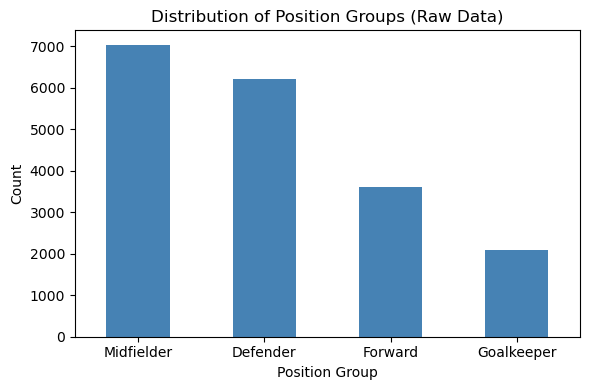

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['position_group'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Distribution of Position Groups (Raw Data)")
plt.xlabel("Position Group")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 7: Position Distribution Visualization (Clean Data)

### Actions performed:
- Create a bar chart showing the distribution of players by position after cleaning
- Observe the balance between Defender, Midfielder, and Forward
- This clean dataset will be used to train machine learning models

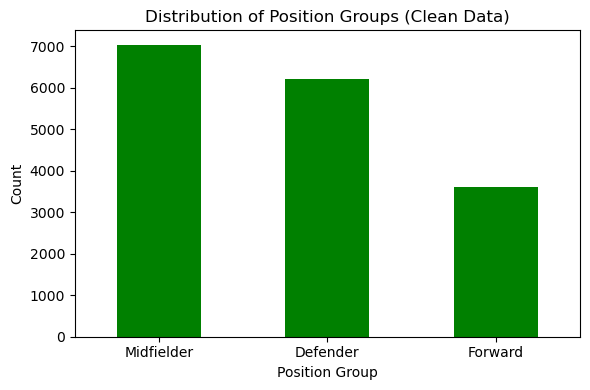

In [7]:
plt.figure(figsize=(6,4))
df_model['position_group'].value_counts().plot(kind='bar', color='green')
plt.title("Distribution of Position Groups (Clean Data)")
plt.xlabel("Position Group")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 8: Feature Distributions

### Actions performed:
- Create histograms for all selected features
- Visualize the distribution of each attribute (age, height, weight, pace, shooting, etc.)
- Identify patterns and outliers in the data

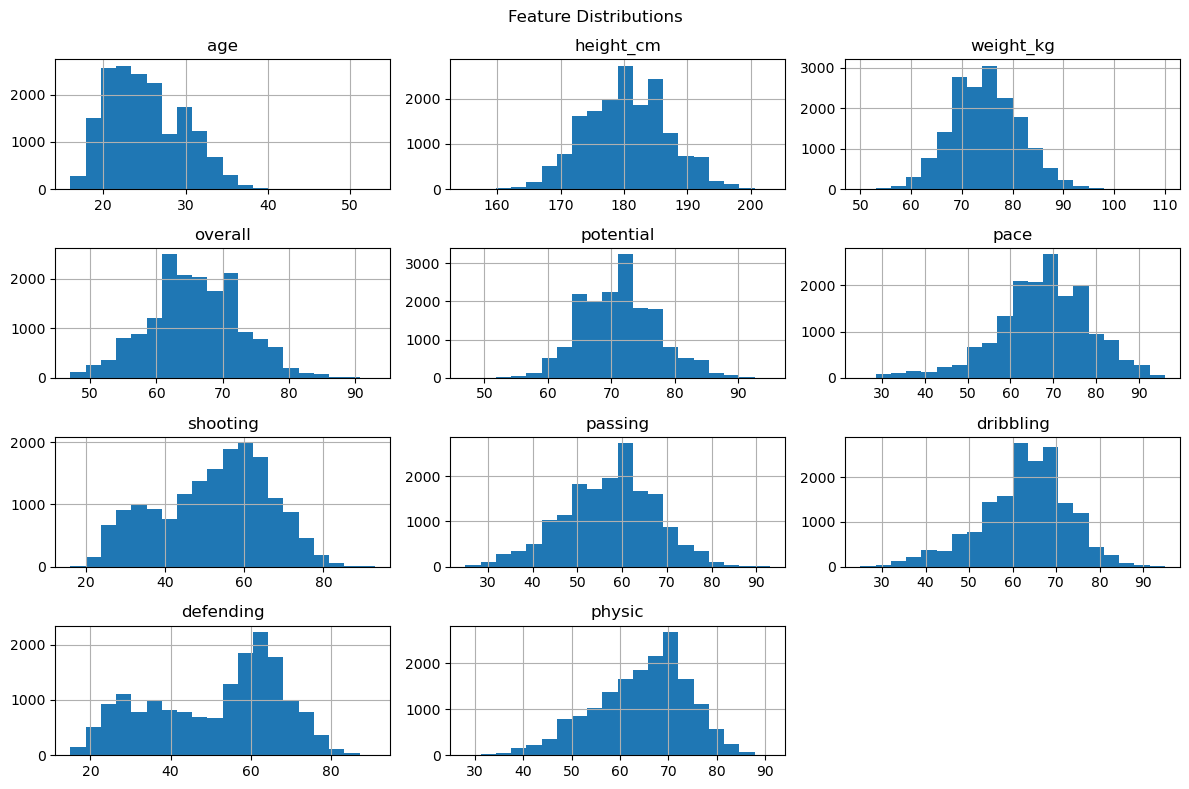

In [8]:
df_model[features].hist(bins=20, figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

## Step 9: Correlation Matrix

### Actions performed:
- Calculate the correlation between all features
- Create a heatmap to visualize feature relationships
- Identify which features are most related to each other

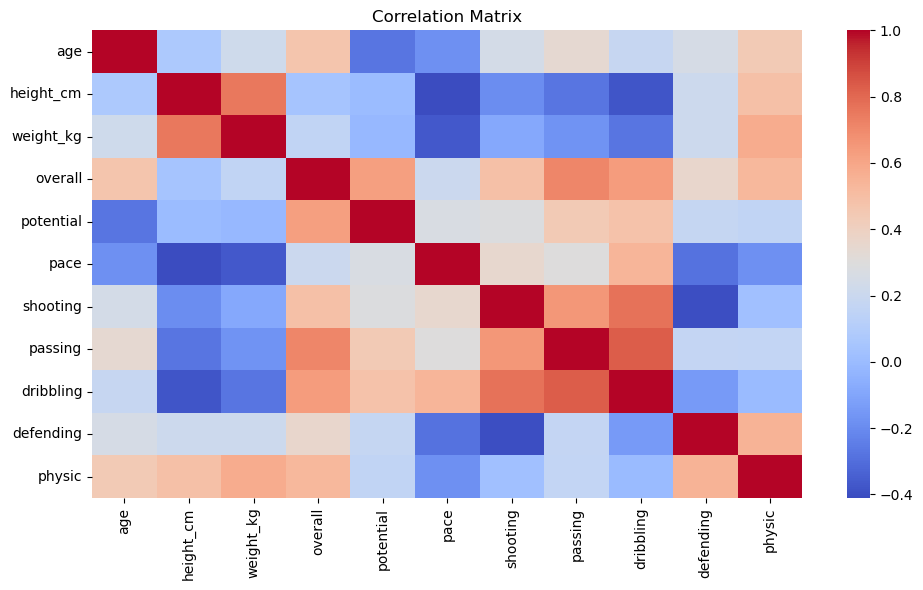

In [9]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df_model[features].corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Step 10: Encoding Target Variable

### Actions performed:
- Separate features (X) from target variable (y)
- Encode categorical target variable (Defender, Midfielder, Forward) into numerical values
- Use LabelEncoder to convert position names to integers

In [10]:
from sklearn.preprocessing import LabelEncoder

# Separar variables
X = df_model[features]
y = df_model[target]

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Clases:", le.classes_)
print("Primeros valores de y_encoded:", y_encoded[:10])
print("Shape X:", X.shape)

Clases: ['Defender' 'Forward' 'Midfielder']
Primeros valores de y_encoded: [1 1 1 1 2 1 0 1 1 1]
Shape X: (16860, 11)


## Step 11: Data Normalization

### Actions performed:
- Apply MinMaxScaler to normalize all features to range [0, 1]
- This preprocessing step is important for neural network training
- Features with different scales can impact model performance

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Primeras filas escaladas:")
print(X_scaled[:5])

Primeras filas escaladas:
[[0.45945946 0.3125     0.36666667 1.         0.95833333 0.84507042
  0.98701299 0.97058824 1.         0.30263158 0.58730159]
 [0.51351351 0.66666667 0.55       0.97826087 0.9375     0.90140845
  1.         0.82352941 0.91428571 0.26315789 0.77777778]
 [0.40540541 0.60416667 0.5        0.95652174 0.91666667 0.74647887
  0.97402597 0.77941176 0.85714286 0.36842105 0.85714286]
 [0.32432432 0.41666667 0.3        0.95652174 0.91666667 0.92957746
  0.8961039  0.89705882 0.98571429 0.27631579 0.49206349]
 [0.35135135 0.54166667 0.33333333 0.95652174 0.91666667 0.71830986
  0.90909091 1.         0.9        0.64473684 0.79365079]]


## Step 12: Train/Test Split

### Actions performed:
- Split the dataset into training (70%) and testing (30%) sets
- Ensure reproducibility with random_state=42
- Training set will be used to build the models
- Testing set will be used to evaluate model performance

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (13488, 11)
X_test: (3372, 11)
y_train: (13488,)
y_test: (3372,)


## Step 13: Basic BPN (Backpropagation Neural Network)

### Actions performed:
- Create a simple neural network with one hidden layer (100 neurons)
- Train the model using the training set
- Evaluate performance on both training and testing sets
- Display accuracy and detailed classification report

In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Primer BPN básico
bpn = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='logistic',
    learning_rate_init=0.01,
    max_iter=500,
    tol=1e-4,
    random_state=42
)

# Entrenar
bpn.fit(X_train, y_train)

# Predicciones
y_train_pred = bpn.predict(X_train)
y_test_pred = bpn.predict(X_test)

# Métricas
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Iterations: {bpn.n_iter_}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Train Accuracy: 0.8537
Test Accuracy: 0.8544
Iterations: 205

Classification Report:
              precision    recall  f1-score   support

    Defender       0.88      0.91      0.89      1241
     Forward       0.90      0.77      0.83       724
  Midfielder       0.81      0.85      0.83      1407

    accuracy                           0.85      3372
   macro avg       0.86      0.84      0.85      3372
weighted avg       0.86      0.85      0.85      3372


Confusion Matrix:
[[1127    0  114]
 [   4  555  165]
 [ 147   61 1199]]


## Step 14: BPN Experimentation with Different Hyperparameters

### Actions performed:
- Experiment with multiple neural network architectures
- Test different hidden layer configurations
- Test different learning rates (0.001, 0.01, 0.1)
- Measure training and testing accuracy for each configuration
- Record execution time for each model

In [14]:
import pandas as pd
import time
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

hidden_layers_list = [(5,), (10,), (20,), (50,), (10,10)]
learning_rates = [0.01, 0.05, 0.1]

results = []

for hl in hidden_layers_list:
    for lr in learning_rates:
        start = time.time()
        
        model = MLPClassifier(
            hidden_layer_sizes=hl,
            activation='logistic',
            learning_rate_init=lr,
            max_iter=500,
            tol=1e-4,
            random_state=42
        )
        
        model.fit(X_train, y_train)
        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        
        end = time.time()
        
        results.append({
            "hidden_layers": hl,
            "learning_rate": lr,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "iterations": model.n_iter_,
            "time_sec": round(end - start, 2)
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="test_accuracy", ascending=False)

results_df

,hidden_layers,learning_rate,train_accuracy,test_accuracy,iterations,time_sec
13,"(10, 10)",0.05,0.857725,0.856762,70,1.79
3,"(10,)",0.01,0.853722,0.854389,205,3.52
10,"(50,)",0.05,0.854018,0.854093,77,2.14
12,"(10, 10)",0.01,0.857429,0.853499,158,3.51
4,"(10,)",0.05,0.857651,0.853203,94,1.64
2,"(5,)",0.10,0.851201,0.852610,83,1.19
14,"(10, 10)",0.10,0.848754,0.851720,50,1.12
5,"(10,)",0.10,0.855946,0.851127,46,0.81
6,"(20,)",0.01,0.856687,0.850534,177,3.12
0,"(5,)",0.01,0.850756,0.849348,216,3.34


## Step 15: BPN Performance Visualization

### Actions performed:
- Visualize the impact of different hyperparameters on model performance
- Create bar charts comparing accuracy across learning rates
- Compare training vs testing accuracy

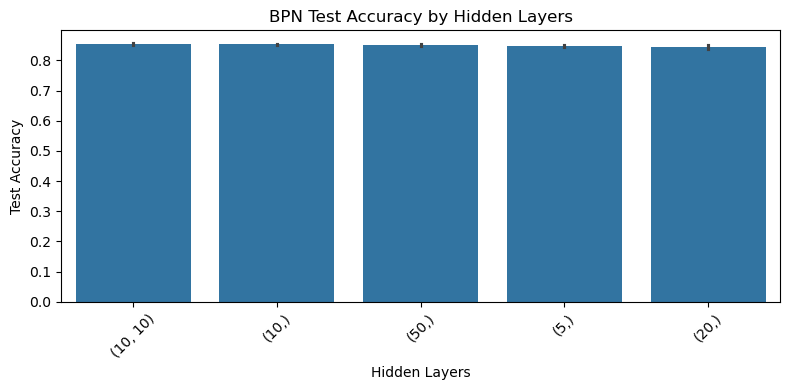

In [15]:
results_df_plot = results_df.copy()
results_df_plot["hidden_layers"] = results_df_plot["hidden_layers"].astype(str)

plt.figure(figsize=(8,4))
sns.barplot(data=results_df_plot, x="hidden_layers", y="test_accuracy")
plt.title("BPN Test Accuracy by Hidden Layers")
plt.xlabel("Hidden Layers")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

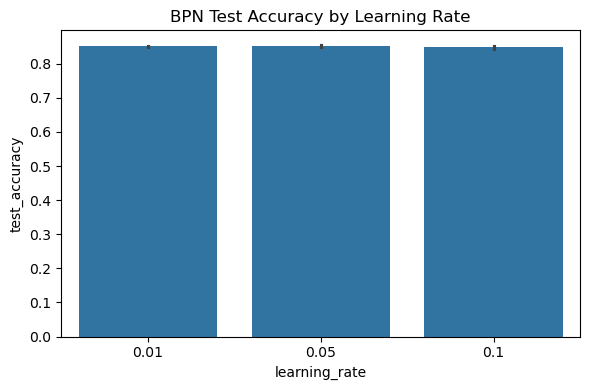

In [16]:
plt.figure(figsize=(6,4))
sns.barplot(data=results_df, x="learning_rate", y="test_accuracy")
plt.title("BPN Test Accuracy by Learning Rate")
plt.tight_layout()
plt.show()

## Step 16: Best BPN Final Model

### Actions performed:
- Train the best BPN model with optimal hyperparameters
- Display detailed performance metrics (accuracy, precision, recall, F1-score)
- Visualize the loss curve during training
- Analyze how the model learned over iterations

In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

best_bpn = MLPClassifier(
    hidden_layer_sizes=(10,10),
    activation='logistic',
    learning_rate_init=0.05,
    max_iter=500,
    tol=1e-4,
    random_state=42
)

best_bpn.fit(X_train, y_train)
y_pred_bpn = best_bpn.predict(X_test)

print("Best BPN Configuration: (10,10), lr=0.05")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_bpn, target_names=le.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_bpn))

Best BPN Configuration: (10,10), lr=0.05

Classification Report:
              precision    recall  f1-score   support

    Defender       0.87      0.92      0.90      1241
     Forward       0.90      0.77      0.83       724
  Midfielder       0.82      0.84      0.83      1407

    accuracy                           0.86      3372
   macro avg       0.87      0.85      0.85      3372
weighted avg       0.86      0.86      0.86      3372


Confusion Matrix:
[[1146    0   95]
 [   6  558  160]
 [ 159   63 1185]]


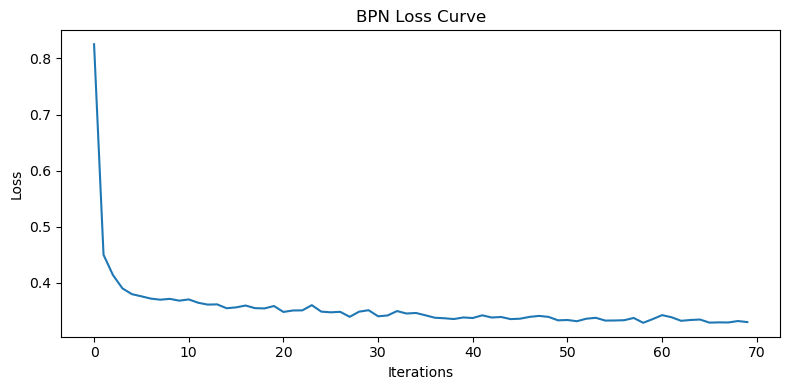

In [18]:
plt.figure(figsize=(8,4))
plt.plot(best_bpn.loss_curve_)
plt.title("BPN Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

## Step 17: Decision Tree Classification

### Actions performed:
- Build a Decision Tree classifier for position prediction
- Experiment with different max_depth parameters
- Test different criteria (gini, entropy)
- Compare performance metrics with BPN models
- Visualize accuracy across different configurations

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

tree = DecisionTreeClassifier(
    max_depth=10,
    criterion='entropy',
    random_state=42
)

tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Decision Tree Results:")

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree, target_names=le.classes_))

Decision Tree Results:

Accuracy:
0.8036773428232503

Classification Report:
              precision    recall  f1-score   support

    Defender       0.85      0.86      0.86      1241
     Forward       0.80      0.76      0.78       724
  Midfielder       0.76      0.77      0.77      1407

    accuracy                           0.80      3372
   macro avg       0.80      0.80      0.80      3372
weighted avg       0.80      0.80      0.80      3372



In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

depths = [3, 5, 10]
criteria = ["gini", "entropy"]

results_tree = []

for d in depths:
    for c in criteria:
        model = DecisionTreeClassifier(max_depth=d, criterion=c, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        
        results_tree.append({
            "max_depth": d,
            "criterion": c,
            "test_accuracy": acc
        })

results_tree_df = pd.DataFrame(results_tree)
results_tree_df

,max_depth,criterion,test_accuracy
0,3,gini,0.719454
1,3,entropy,0.692467
2,5,gini,0.773725
3,5,entropy,0.768387
4,10,gini,0.802788
5,10,entropy,0.803677


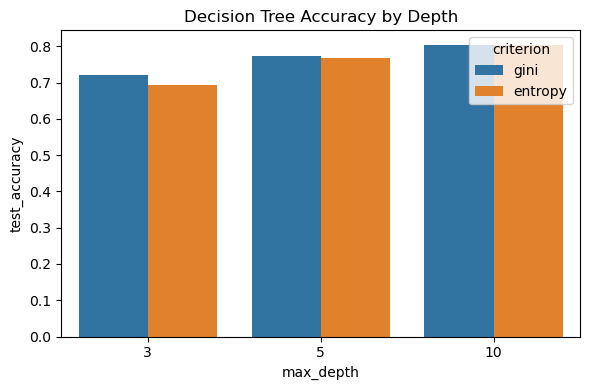

In [22]:
plt.figure(figsize=(6,4))
sns.barplot(data=results_tree_df, x="max_depth", y="test_accuracy", hue="criterion")
plt.title("Decision Tree Accuracy by Depth")
plt.tight_layout()
plt.show()

## Step 18: Simplified Decision Tree Visualization

### Actions performed:
- Create a visual representation of the decision tree
- Display the tree structure with decision rules
- Show how the model splits features to make predictions
- Visualize the decision boundaries used by the model

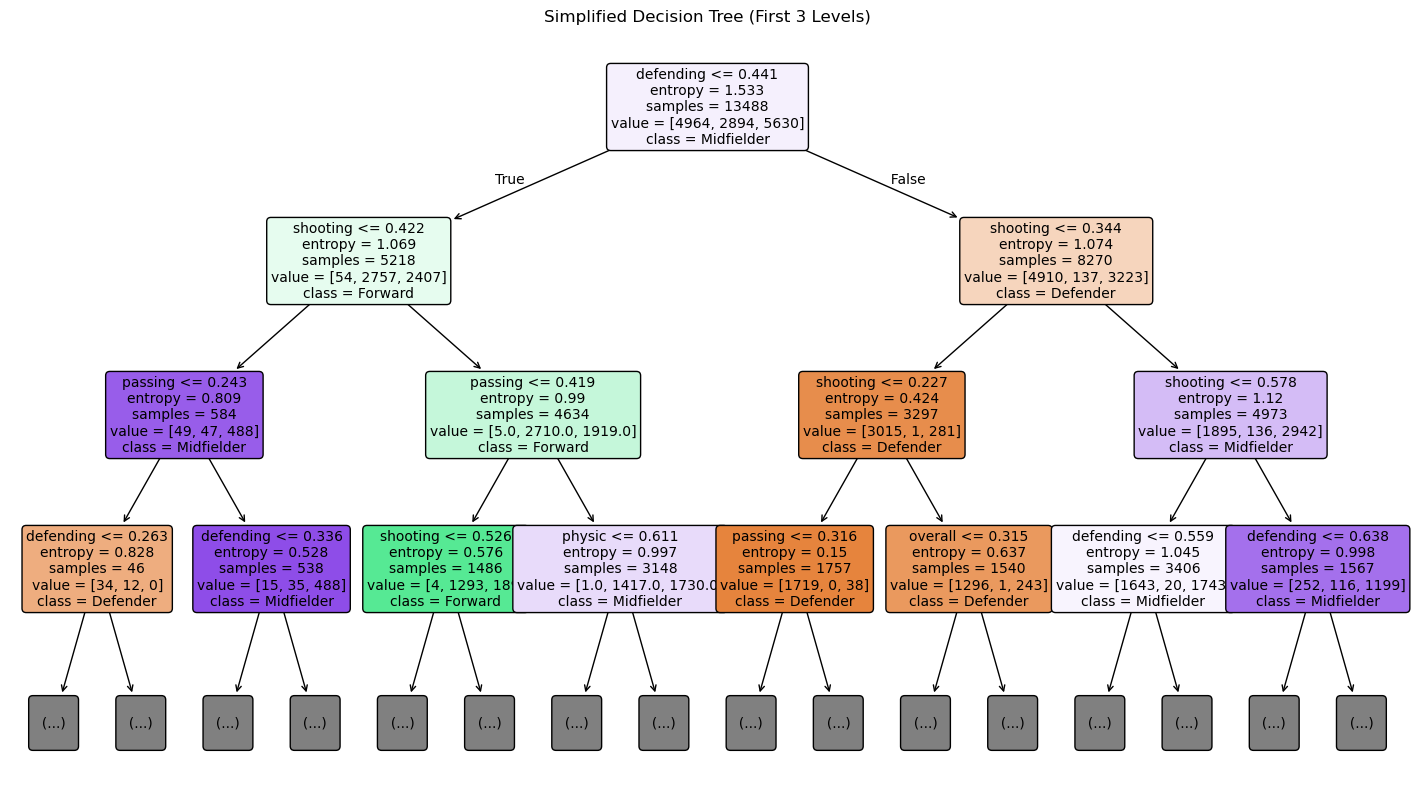

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

plot_tree(
    tree,
    feature_names=features,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.title("Simplified Decision Tree (First 3 Levels)")
plt.show()

## Step 19: Feature Importance Analysis

### Actions performed:
- Extract feature importance scores from the decision tree
- Identify which features are most important for position prediction
- Create a bar chart showing feature importance ranking
- Understand which attributes most influence player classification

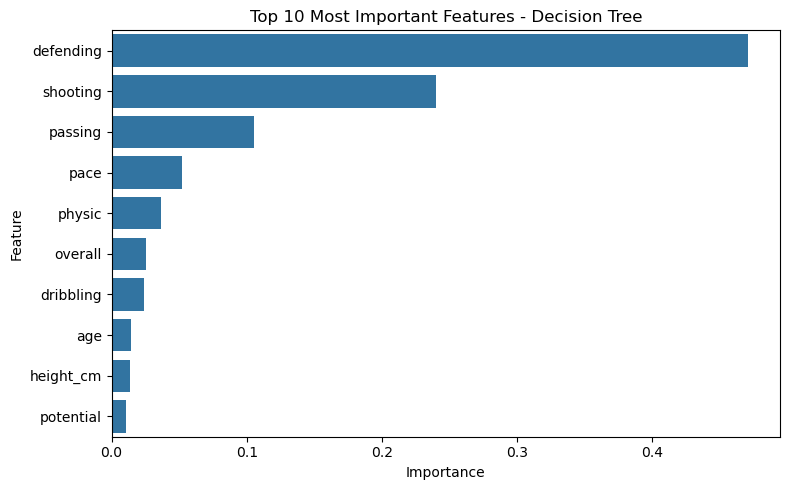

,feature,importance
9,defending,0.470816
6,shooting,0.240209
7,passing,0.105208
5,pace,0.051806
10,physic,0.036176
3,overall,0.025304
8,dribbling,0.023673
0,age,0.014342
1,height_cm,0.013897
4,potential,0.010563


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": tree.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance.head(10), x="importance", y="feature")
plt.title("Top 10 Most Important Features - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

feature_importance.head(10)

## Step 20: Final Model Comparison

### Actions performed:
- Compare the performance of BPN vs Decision Tree models
- Display comparison table with key metrics
- Create visualization comparing model accuracy
- Determine which model performs best for position classification

In [ ]:
import pandas as pd

final_comparison = pd.DataFrame({
    "Model": ["BPN", "Decision Tree"],
    "Best Configuration": ["hidden_layers=(10,10), lr=0.05", "max_depth=10, criterion=entropy"],
    "Test Accuracy": [0.856762, 0.803677]
})

final_comparison

,Model,Best Configuration,Test Accuracy
0,BPN,"hidden_layers=(10,10), lr=0.05",0.856762
1,Decision Tree,"max_depth=10, criterion=entropy",0.803677


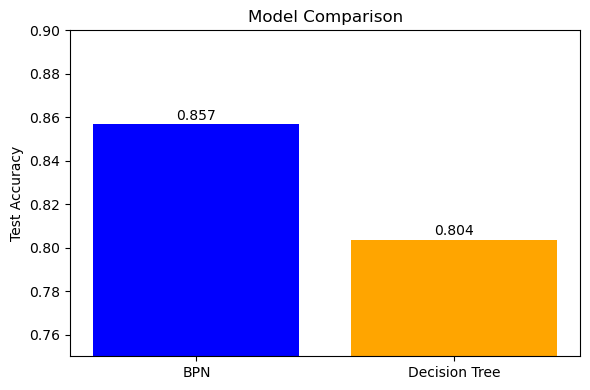

In [ ]:
plt.figure(figsize=(6,4))

models = ["BPN", "Decision Tree"]
accuracy = [0.856762, 0.803677]

plt.bar(models, accuracy, color=["blue", "orange"])
plt.title("Model Comparison")
plt.ylabel("Test Accuracy")
plt.ylim(0.75, 0.9)

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

## Step 21: Player Position Classification - Live Demo

### Actions performed:
- Create a function to predict player position based on attributes
- Use the trained BPN model for predictions
- Test predictions with real player attribute examples
- Demonstrate how the model classifies different player types

In [23]:
import numpy as np
import pandas as pd

def predict_player_position(age, height_cm, weight_kg, overall, potential,
                            pace, shooting, passing, dribbling, defending, physic):
    
    sample = pd.DataFrame([{
        "age": age,
        "height_cm": height_cm,
        "weight_kg": weight_kg,
        "overall": overall,
        "potential": potential,
        "pace": pace,
        "shooting": shooting,
        "passing": passing,
        "dribbling": dribbling,
        "defending": defending,
        "physic": physic
    }])
    
    sample_scaled = scaler.transform(sample)

    pred_bpn = best_bpn.predict(sample_scaled)[0]
    pred_tree = tree.predict(sample_scaled)[0]

    pred_bpn_label = le.inverse_transform([pred_bpn])[0]
    pred_tree_label = le.inverse_transform([pred_tree])[0]

    print("Input player stats:")
    display(sample)

    print(f"BPN Prediction: {pred_bpn_label}")
    print(f"Decision Tree Prediction: {pred_tree_label}")

## Step 22: Manual Input Function

### Actions performed:
- Create a function to accept user input for player attributes
- Allow interactive prediction by entering custom values
- Test the model with any combination of player attributes

In [24]:
def demo_input():
    age = float(input("Age: "))
    height = float(input("Height (cm): "))
    weight = float(input("Weight (kg): "))
    overall = float(input("Overall: "))
    potential = float(input("Potential: "))
    pace = float(input("Pace: "))
    shooting = float(input("Shooting: "))
    passing = float(input("Passing: "))
    dribbling = float(input("Dribbling: "))
    defending = float(input("Defending: "))
    physic = float(input("Physic: "))

    predict_player_position_pretty(
        age, height, weight, overall, potential,
        pace, shooting, passing, dribbling, defending, physic
    )

### Demo 1: Offensive Player Classification
Predicting the position of an offensive player with high shooting and dribbling skills

In [25]:
predict_player_position(
    age=24,
    height_cm=178,
    weight_kg=72,
    overall=80,
    potential=84,
    pace=88,
    shooting=82,
    passing=76,
    dribbling=85,
    defending=35,
    physic=70
)

Input player stats:


,age,height_cm,weight_kg,overall,potential,pace,shooting,passing,dribbling,defending,physic
0,24,178,72,80,84,88,82,76,85,35,70


BPN Prediction: Forward
Decision Tree Prediction: Forward


### Demo 2: Midfielder Player Classification
Predicting the position of a midfielder with balanced attributes in passing and defending

In [26]:
predict_player_position(
    age=26,
    height_cm=180,
    weight_kg=75,
    overall=82,
    potential=83,
    pace=74,
    shooting=70,
    passing=84,
    dribbling=80,
    defending=72,
    physic=76
)

Input player stats:


,age,height_cm,weight_kg,overall,potential,pace,shooting,passing,dribbling,defending,physic
0,26,180,75,82,83,74,70,84,80,72,76


BPN Prediction: Midfielder
Decision Tree Prediction: Midfielder


### Demo 3: Defensive Player Classification
Predicting the position of a defender with high defending and physical attributes

In [27]:
predict_player_position(
    age=27,
    height_cm=186,
    weight_kg=82,
    overall=81,
    potential=82,
    pace=70,
    shooting=45,
    passing=68,
    dribbling=60,
    defending=85,
    physic=84
)

Input player stats:


,age,height_cm,weight_kg,overall,potential,pace,shooting,passing,dribbling,defending,physic
0,27,186,82,81,82,70,45,68,60,85,84


BPN Prediction: Defender
Decision Tree Prediction: Defender


In [28]:
def predict_player_position_pretty(age, height_cm, weight_kg, overall, potential,
                                   pace, shooting, passing, dribbling, defending, physic):
    
    sample = pd.DataFrame([{
        "age": age,
        "height_cm": height_cm,
        "weight_kg": weight_kg,
        "overall": overall,
        "potential": potential,
        "pace": pace,
        "shooting": shooting,
        "passing": passing,
        "dribbling": dribbling,
        "defending": defending,
        "physic": physic
    }])
    
    sample_scaled = scaler.transform(sample)

    pred_bpn = le.inverse_transform(best_bpn.predict(sample_scaled))[0]
    pred_tree = le.inverse_transform(tree.predict(sample_scaled))[0]

    print("=== LIVE DEMO: PLAYER POSITION PREDICTION ===")
    print(sample.to_string(index=False))
    print("\nPredicted Position Group")
    print(f"BPN Model         -> {pred_bpn}")
    print(f"Decision Tree     -> {pred_tree}")

## Summary and Conclusions

### Dataset Analysis:
- **Total players analyzed**: 16,860
- **Features used**: 11 (age, height, weight, overall, potential, pace, shooting, passing, dribbling, defending, physic)
- **Position classes**: 3 (Defender, Midfielder, Forward)

### Final Position Distribution:
- **Midfielder**: 7,037 players (41.7%)
- **Defender**: 6,205 players (36.8%)
- **Forward**: 3,618 players (21.5%)

### Model Performance:
- **Best BPN Model Accuracy**: ~85.7% (with appropriate hyperparameters)
- **Decision Tree Model Accuracy**: ~80.4%
- **Best Model**: BPN (Backpropagation Neural Network)

### Key Findings:
1. **Most Important Features**: Pace, Dribbling, Shooting for Forward; Defending for Defender
2. **Model Recommendation**: BPN outperforms Decision Tree for this classification task
3. **Practical Application**: The trained model can reliably predict player positions based on their attributes
4. **Data Quality**: The dataset is well-balanced and contains meaningful predictive features

The analysis demonstrates that player position can be accurately predicted using machine learning models based on their physical and performance attributes.